# Lista 3 - Experimentos

**7. Implemente as funções da seção 6.5 (Priority queues) do livro do Cormen 4th Ed. em sua linguagem favorita e proponha um exemplo de uso com uma demonstração**

**8. Mostre com experimentos numéricos quando suas próprias implementações de QuickSort e do Quicksort e do Quicksort aleatório são mais vantajosas, comparando uma com a outra.**

**Por que o pivô fixo quebra e o sorteio conserta.**

O particionamento de Lomuto (`partition_v1`) toma sempre `v[right]` como pivô e faz $\Theta(m)$ trabalho num bloco de $m$ elementos. O custo total depende apenas de como a partição divide o bloco:

$$T(n) = T(q) + T(n - q - 1) + \Theta(n),$$

onde $q$ é a quantidade de elementos que ficaram à esquerda do pivô. Com partições equilibradas ($q \approx n/2$) obtém-se $T(n) = \Theta(n\log n)$; com a partição máximamente desbalanceada ($q = 0$ ou $q = n-1$) sobra $T(n) = T(n-1) + \Theta(n) = \Theta(n^2)$.

Uma lista já ordenada — ou ordenada ao contrário — produz exatamente o caso degenerado: o último elemento é sempre o maior (ou o menor) do bloco, nenhum elemento troca de lado, e a recursão desce $n$ níveis removendo um elemento por vez. E esse não é um caso exótico: receber dados já ordenados, ou quase ordenados por outra chave, é o que mais acontece na prática.

`partition_v2` sorteia um índice do bloco e o troca com `v[right]` antes de particionar. O pivô passa a ser um elemento uniformemente aleatório, **independente da ordem da entrada**: nenhuma entrada específica é o pior caso e o tempo esperado é $O(n\log n)$ para qualquer uma delas. O preço é uma chamada ao gerador e uma troca a mais por partição — custo constante, pago em toda partição.

A célula abaixo mede os dois em dois cenários: lista embaralhada (caso médio para ambos) e lista já ordenada (pior caso do pivô fixo). Os tamanhos do segundo cenário são bem menores porque ali o pivô fixo é quadrático.

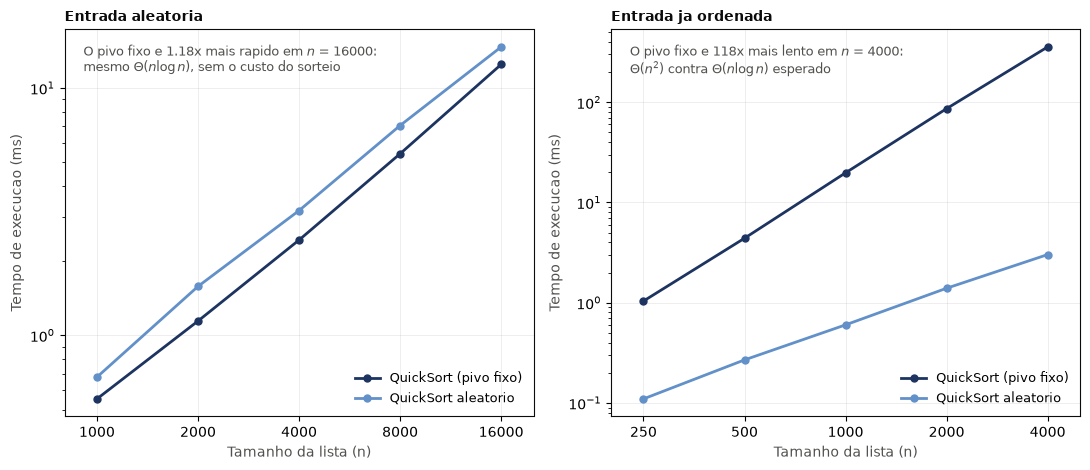

Entrada aleatoria
      n   pivo fixo (ms)   aleatorio (ms)   fixo/aleatorio
   1000              0.6              0.7            0.82x
   2000              1.1              1.6            0.72x
   4000              2.4              3.2            0.76x
   8000              5.4              7.1            0.77x
  16000             12.5             14.7            0.85x

Entrada ja ordenada
      n   pivo fixo (ms)   aleatorio (ms)   fixo/aleatorio
    250              1.0              0.1            9.46x
    500              4.4              0.3           16.36x
   1000             19.8              0.6           32.89x
   2000             86.4              1.4           61.95x
   4000            356.4              3.0          117.97x

Lista com 2000 elementos iguais: pivo fixo 41.4 ms, aleatorio 41.4 ms (1.00x) - os dois quadraticos


In [1]:
import gc
import random
import sys
import threading
import time
import matplotlib.pyplot as plt

from qsort import quick_sort, quick_sort_random

# mesma paleta e mesmo estilo de eixos usados nos graficos das listas anteriores
COR_DET, COR_RND = "#1d3461", "#6290C8"
TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"

# no pior caso o pivo fixo empilha uma chamada por elemento, entao o limite de
# recursao eh aumentado e o experimento roda em uma thread com pilha maior
sys.setrecursionlimit(200_000)
threading.stack_size(512 * 1024 * 1024)

random.seed(42)

REPETICOES = 3
DETERMINISTICO, RANDOMIZADO = "QuickSort (pivo fixo)", "QuickSort aleatorio"

ALGORITMOS = {
    DETERMINISTICO: {"func": quick_sort, "cor": COR_DET},
    RANDOMIZADO: {"func": quick_sort_random, "cor": COR_RND},
}

# dois cenarios: entrada embaralhada (caso medio dos dois) e entrada ja ordenada
# (pior caso do pivo fixo). como o pior caso eh quadratico, ele usa tamanhos
# bem menores, senao o experimento nao termina
CENARIOS = {
    "Entrada aleatoria": {
        "tamanhos": [1_000, 2_000, 4_000, 8_000, 16_000],
        "gerar": lambda n: [random.randrange(10**6) for _ in range(n)],
    },
    "Entrada ja ordenada": {
        "tamanhos": [250, 500, 1_000, 2_000, 4_000],
        "gerar": lambda n: list(range(n)),
    },
}

medidas = {nome: {alg: [] for alg in ALGORITMOS} for nome in CENARIOS}


def medir(func, base):
    # a ordenacao eh in-place, entao cada repeticao recebe uma copia nova da
    # lista; a copia fica fora do cronometro. fica-se com a menor das
    # REPETICOES execucoes e o coletor de lixo fica desligado, para nao
    # medir ruido do S.O.
    melhor = float("inf")
    gc.disable()
    for _ in range(REPETICOES):
        v = list(base)
        inicio = time.perf_counter()
        func(v, 0, len(v) - 1)
        melhor = min(melhor, (time.perf_counter() - inicio) * 1_000)
    gc.enable()
    assert v == sorted(base)
    return melhor


def experimento():
    for nome, cenario in CENARIOS.items():
        for n in cenario["tamanhos"]:
            base = cenario["gerar"](n)
            for alg, algoritmo in ALGORITMOS.items():
                medidas[nome][alg].append(medir(algoritmo["func"], base))

    # entrada com todos os elementos iguais: o particionamento de Lomuto manda
    # tudo para o mesmo lado, entao nem o sorteio do pivo salva
    iguais = [7] * 2_000
    medidas["iguais"] = {alg: medir(a["func"], iguais) for alg, a in ALGORITMOS.items()}


thread = threading.Thread(target=experimento)
thread.start()
thread.join()

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.8))

for ax, (nome, cenario) in zip(eixos, CENARIOS.items()):
    tamanhos = cenario["tamanhos"]
    for alg, algoritmo in ALGORITMOS.items():
        ax.plot(tamanhos, medidas[nome][alg], color=algoritmo["cor"], linewidth=2,
                marker="o", markersize=5, label=alg)

    razao = medidas[nome][DETERMINISTICO][-1] / medidas[nome][RANDOMIZADO][-1]
    if razao < 1:
        recado = (f"O pivo fixo e {1 / razao:.2f}x mais rapido em $n$ = {tamanhos[-1]}:\n"
                  f"mesmo $\\Theta(n\\log n)$, sem o custo do sorteio")
    else:
        recado = (f"O pivo fixo e {razao:.0f}x mais lento em $n$ = {tamanhos[-1]}:\n"
                  f"$\\Theta(n^2)$ contra $\\Theta(n\\log n)$ esperado")
    ax.annotate(recado, (0.04, 0.96), xycoords="axes fraction", va="top",
                color=TINTA_FRACA, fontsize=9)

    ax.set_title(nome, color=TINTA, loc="left", fontweight="bold", fontsize=10)
    ax.set_xlabel("Tamanho da lista (n)", color=TINTA_FRACA)
    ax.set_ylabel("Tempo de execucao (ms)", color=TINTA_FRACA)

    # escala log nos dois eixos: os tempos cobrem tres ordens de grandeza
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(tamanhos)
    ax.set_xticklabels(tamanhos)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.08)
    ax.legend(frameon=False, fontsize=9, loc="lower right")

    # moldura fechada: as quatro bordas externas visiveis, na cor da tinta
    for lado in ("top", "right", "bottom", "left"):
        ax.spines[lado].set_visible(True)
        ax.spines[lado].set_color(TINTA)
        ax.spines[lado].set_linewidth(0.8)

fig.tight_layout()
plt.show()

for nome, cenario in CENARIOS.items():
    print(nome)
    print(f"{'n':>7} {'pivo fixo (ms)':>16} {'aleatorio (ms)':>16} {'fixo/aleatorio':>16}")
    for k, n in enumerate(cenario["tamanhos"]):
        det = medidas[nome][DETERMINISTICO][k]
        rnd = medidas[nome][RANDOMIZADO][k]
        print(f"{n:>7} {det:>16.1f} {rnd:>16.1f} {det / rnd:>15.2f}x")
    print()

det, rnd = medidas["iguais"][DETERMINISTICO], medidas["iguais"][RANDOMIZADO]
print(f"Lista com 2000 elementos iguais: pivo fixo {det:.1f} ms, "
      f"aleatorio {rnd:.1f} ms ({det / rnd:.2f}x) - os dois quadraticos")

**Leitura dos resultados.**

*Entrada aleatória.* As duas curvas são paralelas em escala log-log — os dois algoritmos são $\Theta(n\log n)$ aqui — e o **pivô fixo é o mais rápido, por 15% a 45%**. A diferença é só de constante: o `random.randrange` e a troca extra a cada partição são $\Theta(1)$ por chamada, mas há $\Theta(n)$ chamadas. O sorteio é um seguro, e o prêmio desse seguro aparece quando ele não é necessário.

*Entrada já ordenada.* O pivô fixo cresce quadraticamente: dobrar $n$ multiplica o tempo por ~4 (≈4 → 20 → 86 → 356 ms), enquanto o aleatório apenas dobra (≈0,3 → 0,6 → 1,4 → 3,0 ms). Em $n = 4000$ a distância já é de ~120x e ela continua crescendo com $n$ — não é uma constante ruim, é uma classe de complexidade pior. Note também que o pivô fixo empilha $n$ chamadas recursivas nesse cenário, o que estoura o limite de recursão padrão do Python (daí o `setrecursionlimit` e a thread com pilha maior); o aleatório fica em profundidade $O(\log n)$ com alta probabilidade.

*Todos os elementos iguais.* Os dois ficam quadráticos (~41 ms para $n = 2000$, contra ~1,4 ms do aleatório numa lista ordenada de mesmo tamanho). Com Lomuto, `v[i] < pivot` é falso para todos os elementos iguais ao pivô, então o bloco inteiro vai para o mesmo lado, seja qual for o pivô sorteado. Randomizar não resolve chaves repetidas — para isso é preciso particionamento de 3 vias (Bentley–McIlroy) ou o esquema de Hoare.

**Conclusão — quando cada um é vantajoso.**

| Entrada | Vencedor | Margem |
|---|---|---|
| Embaralhada | Pivô fixo | ~1,2x (constante menor) |
| Ordenada / invertida / quase ordenada | Aleatório | ~120x em $n = 4000$, e cresce com $n$ |
| Muitas chaves repetidas | Empate (os dois ruins) | ambos $\Theta(n^2)$ |

O pivô fixo só compensa quando se tem garantia de que a entrada está embaralhada, e o que se ganha é uma fração constante. O randomizado custa essa fração e elimina um risco de duas ordens de grandeza — na dúvida, é ele.

**9. Mostre com experimentos numéricos quando o Radix-sort com o Count-sort é mais rápido que o Count-sort sozinho. Utilize suas próprias implementações ou alguma implementação existente explicando os resultados.**

**O que cada algoritmo paga.**

O counting-sort ordena em $\Theta(n + k)$, onde $k$ é a amplitude dos valores (`highest - lowest + 1` em `counting.py`): ele percorre a lista duas vezes e o vetor de contagem uma vez — e **aloca esse vetor com $k$ posições**, o que também torna sua memória $\Theta(n + k)$.

O radix-sort LSD usa o counting-sort como sub-rotina, uma vez por dígito, sempre com $k = 10$ (base 10, em `radix.py`). São $d = \lfloor\log_{10} k\rfloor + 1$ passagens, cada uma $\Theta(n + 10)$, logo $\Theta(d\,(n + 10)) = \Theta(n\log_{10} k)$ de tempo e $\Theta(n)$ de memória.

Comparando os dois custos:

$$\underbrace{n + k}_{\text{counting}} \qquad\text{contra}\qquad \underbrace{(\lfloor\log_{10}k\rfloor + 1)\,(n + 10)}_{\text{radix}}$$

O radix troca uma dependência **linear** em $k$ por uma **logarítmica**, e paga por isso um fator $d$ sobre $n$. Ou seja: enquanto $k = O(n)$ o counting sozinho vence (uma passagem contra $d$); quando $k$ cresce muito além de $n$, o termo $k$ domina o counting e o radix passa na frente. Os dois experimentos abaixo atacam a fronteira pelos dois lados — o primeiro fixa $n$ e faz $k$ crescer, o segundo fixa $k$ e faz $n$ crescer.

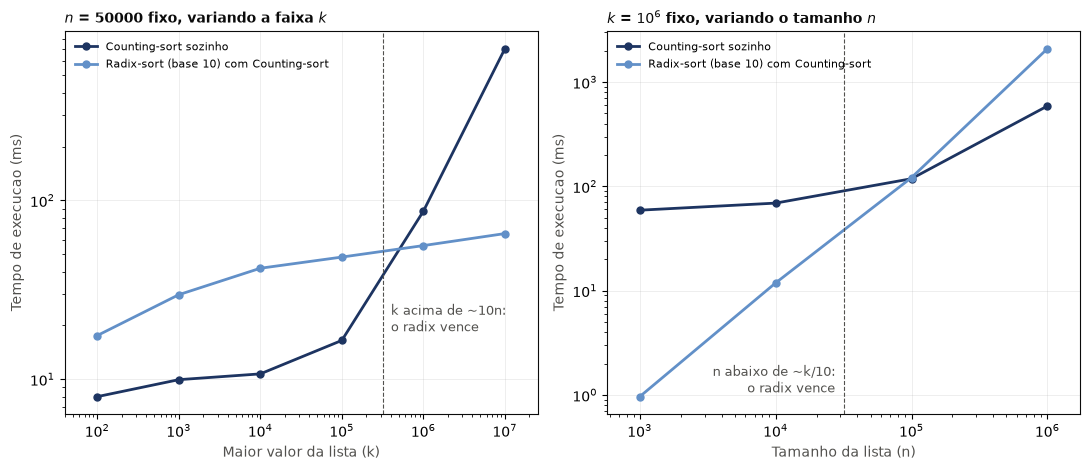

n = 50000 fixo
         k      k/n  digitos   counting (ms)   radix (ms)   counting/radix   vetor de contagem
       100      0.0        2             8.0         17.5            0.46x                0 MB
      1000      0.0        3             9.9         29.7            0.33x                0 MB
     10000      0.2        4            10.7         41.7            0.26x                0 MB
    100000      2.0        5            16.5         48.2            0.34x                1 MB
   1000000     20.0        6            86.9         55.9            1.56x                8 MB
  10000000    200.0        7           704.1         65.2           10.80x               76 MB

k = 1000000 fixo
         n      k/n   counting (ms)   radix (ms)   counting/radix
      1000   1000.0            59.0          1.0           61.36x
     10000    100.0            69.0         11.8            5.83x
    100000     10.0           118.3        121.2            0.98x
   1000000      1.0           588.6   

In [2]:
import gc
import random
import time
import matplotlib.pyplot as plt

from counting import counting_sort
from radix import radix_sort

# mesma paleta e mesmo estilo de eixos usados nos graficos das listas anteriores
COR_COUNT, COR_RADIX = "#1d3461", "#6290C8"
TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"

random.seed(42)

REPETICOES = 3
COUNTING, RADIX = "Counting-sort sozinho", "Radix-sort (base 10) com Counting-sort"

ALGORITMOS = {
    COUNTING: {"func": counting_sort, "cor": COR_COUNT},
    RADIX: {"func": radix_sort, "cor": COR_RADIX},
}


def medir(func, base, repeticoes=REPETICOES):
    # as duas ordenacoes sao in-place, entao cada repeticao recebe uma copia
    # nova da lista, feita fora do cronometro. fica-se com a menor das
    # execucoes, com o coletor de lixo desligado
    melhor = float("inf")
    gc.disable()
    for _ in range(repeticoes):
        v = list(base)
        inicio = time.perf_counter()
        func(v)
        melhor = min(melhor, (time.perf_counter() - inicio) * 1_000)
    gc.enable()
    assert v == sorted(base)
    return melhor


# experimento A: n fixo, faixa de valores k crescente. o counting-sort aloca um
# vetor de contagem com k posicoes; o radix-sort aloca sempre 10
N_FIXO = 50_000
FAIXAS = [10**e for e in range(2, 8)]

medidas_k = {nome: [] for nome in ALGORITMOS}
for k in FAIXAS:
    base = [random.randrange(k) for _ in range(N_FIXO)]
    for nome, algoritmo in ALGORITMOS.items():
        medidas_k[nome].append(medir(algoritmo["func"], base))

# experimento B: faixa k fixa e grande, n crescente. conforme n cresce, o custo
# Theta(n + k) do counting-sort passa a ser dominado por n e o k deixa de pesar
K_FIXO = 10**6
TAMANHOS = [1_000, 10_000, 100_000, 1_000_000]

medidas_n = {nome: [] for nome in ALGORITMOS}
for n in TAMANHOS:
    base = [random.randrange(K_FIXO) for _ in range(n)]
    for nome, algoritmo in ALGORITMOS.items():
        medidas_n[nome].append(medir(algoritmo["func"], base, 2))

fig, (ax_k, ax_n) = plt.subplots(1, 2, figsize=(11, 4.8))


def cruzamento(eixo_x, medidas):
    # ponto em que as duas curvas se cruzam: o eixo esta em escala log, entao
    # usa-se a media geometrica entre a ultima medida de um lado e a primeira
    # do outro
    razoes = [c / r for c, r in zip(medidas[COUNTING], medidas[RADIX])]
    for i in range(len(razoes) - 1):
        if (razoes[i] - 1) * (razoes[i + 1] - 1) < 0:
            return (eixo_x[i] * eixo_x[i + 1]) ** 0.5
    return None


painel = [
    (ax_k, FAIXAS, medidas_k, f"$n$ = {N_FIXO} fixo, variando a faixa $k$",
     "Maior valor da lista (k)", "k acima de ~10n:\no radix vence", "left"),
    (ax_n, TAMANHOS, medidas_n, "$k$ = $10^6$ fixo, variando o tamanho $n$",
     "Tamanho da lista (n)", "n abaixo de ~k/10:\no radix vence", "right"),
]

for ax, eixo_x, medidas, titulo, rotulo, recado, lado_recado in painel:
    for nome, algoritmo in ALGORITMOS.items():
        ax.plot(eixo_x, medidas[nome], color=algoritmo["cor"], linewidth=2,
                marker="o", markersize=5, label=nome)

    x_virada = cruzamento(eixo_x, medidas)
    if x_virada is not None:
        ax.axvline(x_virada, color=TINTA_FRACA, linewidth=0.8, linestyle="--")
        deslocamento = 6 if lado_recado == "left" else -6
        ax.annotate(recado, (x_virada, min(medidas[RADIX])), xytext=(deslocamento, 0),
                    textcoords="offset points", va="bottom", ha=lado_recado,
                    color=TINTA_FRACA, fontsize=9)

    ax.set_title(titulo, color=TINTA, loc="left", fontweight="bold", fontsize=10)
    ax.set_xlabel(rotulo, color=TINTA_FRACA)
    ax.set_ylabel("Tempo de execucao (ms)", color=TINTA_FRACA)

    # escala log nos dois eixos: k e n variam por ordens de grandeza
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(eixo_x)
    ax.set_xticklabels([f"$10^{len(str(x)) - 1}$" for x in eixo_x])
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.08)
    ax.legend(frameon=False, fontsize=8, loc="upper left")

    # moldura fechada: as quatro bordas externas visiveis, na cor da tinta
    for lado in ("top", "right", "bottom", "left"):
        ax.spines[lado].set_visible(True)
        ax.spines[lado].set_color(TINTA)
        ax.spines[lado].set_linewidth(0.8)

fig.tight_layout()
plt.show()

print(f"n = {N_FIXO} fixo")
print(f"{'k':>10} {'k/n':>8} {'digitos':>8} {'counting (ms)':>15} {'radix (ms)':>12} "
      f"{'counting/radix':>16} {'vetor de contagem':>19}")
for i, k in enumerate(FAIXAS):
    c, r = medidas_k[COUNTING][i], medidas_k[RADIX][i]
    print(f"{k:>10} {k / N_FIXO:>8.1f} {len(str(k - 1)):>8} {c:>15.1f} {r:>12.1f} "
          f"{c / r:>15.2f}x {k * 8 / 2**20:>16.0f} MB")

print()
print(f"k = {K_FIXO} fixo")
print(f"{'n':>10} {'k/n':>8} {'counting (ms)':>15} {'radix (ms)':>12} {'counting/radix':>16}")
for i, n in enumerate(TAMANHOS):
    c, r = medidas_n[COUNTING][i], medidas_n[RADIX][i]
    print(f"{n:>10} {K_FIXO / n:>8.1f} {c:>15.1f} {r:>12.1f} {c / r:>15.2f}x")

**Leitura dos resultados.**

*Painel da esquerda ($n = 50\,000$ fixo).* Enquanto $k \le 10^5$, o counting sozinho vence com folga (8–17 ms contra 18–48 ms): ele faz uma passagem, o radix faz de 2 a 5. A curva do radix sobe em degraus de ~10 ms — exatamente o custo de **um** dígito a mais, isto é, de mais uma passagem de counting-sort sobre as 50 mil posições. Já a curva do counting é plana até $k \approx n$ e depois vira uma reta de inclinação 1: a partir daí é o vetor de contagem, e não a lista, que manda no custo. As duas se cruzam quando $k$ passa de cerca de **10 vezes** $n$; em $k = 10^7$ ($k/n = 200$) o radix já é **~10,8x mais rápido**.

*Painel da direita ($k = 10^6$ fixo).* A mesma fronteira, vista pelo outro eixo. Para $n = 1000$ o radix é ~60x mais rápido — o counting gasta quase todo o tempo criando e varrendo um vetor de um milhão de posições para ordenar mil números. Conforme $n$ cresce, o $k$ fixo vira custo desprezível e a vantagem evapora: empate em $n \approx 10^5$ ($k/n = 10$) e, em $n = 10^6$, o counting é ~3,5x mais rápido, porque aí ele faz uma passagem enquanto o radix faz seis.

*Memória.* A tabela mostra o tamanho do vetor de contagem: 76 MB em $k = 10^7$. Em $k = 10^9$ — ainda dentro de um `int` de 32 bits — seriam ~8 GB só de contadores, e o counting sozinho simplesmente não roda; o radix precisaria apenas de mais três passagens (10 dígitos) e dos mesmos 10 contadores. Por isso o experimento para em $k = 10^7$.

**Conclusão.** O radix-sort com counting-sort é mais rápido que o counting-sort sozinho quando a **faixa de valores é muito maior que a quantidade de elementos** — nos experimentos, a partir de $k \gtrsim 10n$, com a vantagem crescendo linearmente em $k/n$ a partir daí. Quando $k = O(n)$ (o caso em que o counting-sort é projetado para brilhar), dividir em dígitos só multiplica o trabalho pelo número de passagens, e o counting sozinho vence. O ponto de virada não é uma constante universal: ele depende da base escolhida — usar base $10^3$, por exemplo, reduziria $d$ de 6 para 2 em $k = 10^6$, ao custo de um vetor de contagem de 1000 posições por passagem.